# Reward Competition: High vs. Low Comp Analysis

In [1]:
import sys
import os

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(PROJECT_ROOT)

from Reward_Training.rt_extension import Reward_Training
from rc_extension import Reward_Competition
from pathlib import Path


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from scipy.stats import ttest_ind


In [2]:
experiment_path = r"C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Reward_Competition\combined_cohorts"

manual_scoring_path = r"C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Reward_Competition\combined_cohorts\manual_scoring_combined.xlsx"

# hvl_path = r"C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Reward_Competition\combined_cohorts\HvL_comp_scoring_updated.xlsx"
hvl_path = r"C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Reward_Competition\combined_cohorts\HvL_comp_scoring.xlsx"
# experiment_path = r"C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Reward_Competition\Test"

In [3]:
rc_exp = Reward_Competition(experiment_folder_path=experiment_path, behavior_folder_path=None)
rc_exp.rtc_processing()
rc_exp.read_and_merge_manual_scoring(manual_scoring_path)
rc_exp.remove_tangles(placeholders=True)   # Remove sound cues and winner array indexes where there are tangles
rc_exp.remove_specified_subjects()   # Remove s pecified subjects from the analysis
rc_exp.extract_da_columns()   # Grab only essential columns for analysis
rc_exp.find_first_port_entry_after_sound_cue()
rc_exp.compute_EI_DA(tone_window = (-4,20),
                     pe_window=(-4,20),
                     baseline_window=(-2,0)
)
# rc_exp.compute_EI_DA_PrePE(tone_window=(-4,10),
#                   pe_window=S(-4,20),
#                   tone_baseline_window=(-2,0),
#                   pe_baseline_window=(-2,0))



rc_exp.compute_rtc_da_metrics().head()
rc_exp.split_by_outcome(placeholders=True)

Found Synapse note file: C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Reward_Competition\combined_cohorts\n5-240912-080246\Notes.txt
read from t=0s to t=2051.77s
Found Synapse note file: C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Reward_Competition\combined_cohorts\n5-240913-094304\Notes.txt
read from t=0s to t=2044.77s
Found Synapse note file: C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Reward_Competition\combined_cohorts\n5-240915-060250\Notes.txt
read from t=0s to t=2044.96s
Found Synapse note file: C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Reward_Competition\combined_cohorts\n5-240915-095000\Notes.txt
read from t=0s to t=2070.66s
Found Synapse note file: C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Reward_Competition\combined_cohorts\n7-240912-095235\Notes.txt
read from t=0s to t=1955.86s
Found Synapse note file: C:\Users\alber\

In [4]:
# After you have built rc and created rc.da_df and ran:
# rc.remove_tangles(...)
# rc.split_by_outcome(...)  (optional but fine)
# and ensured rc.da_df contains filtered_winner_array + filtered_sound_cues

print("da_df columns:", list(rc_exp.da_df.columns))

required = ["subject_name", "file name", "trial", "filtered_winner_array", "filtered_sound_cues"]
missing = [c for c in required if c not in rc_exp.da_df.columns]
print("Missing:", missing)


# Quick sanity check: cue count vs winner_array count on first few rows
for k in range(min(5, len(rc_exp.da_df))):
    row = rc_exp.da_df.iloc[k]
    cues = row.get("filtered_sound_cues", [])
    wins = row.get("filtered_winner_array", [])
    print(k, row["file name"], "n_cues=", len(cues) if isinstance(cues, list) else None,
          "n_wins=", len(wins) if isinstance(wins, list) else None)


da_df columns: ['subject_name', 'file name', 'trial', 'filtered_sound_cues', 'filtered_port_entries', 'filtered_port_entry_offset', 'filtered_winner_array', 'first_PE_after_sound_cue', 'Tone_Time_Axis', 'Tone_Zscore', 'PE_Time_Axis', 'PE_Zscore', 'Tone AUC', 'Tone Max Peak', 'Tone Time of Max Peak', 'Tone Mean Z-score', 'PE AUC', 'PE Max Peak', 'PE Time of Max Peak', 'PE Mean Z-score']
Missing: []
0 nn5-250203-080636 n_cues= 20 n_wins= 19
1 pp5-250203-080636 n_cues= 20 n_wins= 19
2 nn1-250203-085508 n_cues= 30 n_wins= 19
3 nn3-250203-085508 n_cues= 30 n_wins= 19
4 nn6-250203-112333 n_cues= 20 n_wins= 19


In [5]:
rc_exp.da_df.columns


Index(['subject_name', 'file name', 'trial', 'filtered_sound_cues',
       'filtered_port_entries', 'filtered_port_entry_offset',
       'filtered_winner_array', 'first_PE_after_sound_cue', 'Tone_Time_Axis',
       'Tone_Zscore', 'PE_Time_Axis', 'PE_Zscore', 'Tone AUC', 'Tone Max Peak',
       'Tone Time of Max Peak', 'Tone Mean Z-score', 'PE AUC', 'PE Max Peak',
       'PE Time of Max Peak', 'PE Mean Z-score'],
      dtype='object')

In [6]:
import numpy as np
import pandas as pd

ID_COLS = ["subject_name", "file name",'first_PE_after_sound_cue', 'Tone_Time_Axis',
       'Tone_Zscore', 'PE_Time_Axis', 'PE_Zscore',]  # you can add more if you want
EVENT_TIME_COL = "filtered_sound_cues"   # absolute cue timestamps (per event)
WINNER_COL = "filtered_winner_array"     # per-event winner labels (subject id) or NaN for tie

def _as_list(x):
    if isinstance(x, np.ndarray):
        return x.tolist()
    return x if isinstance(x, list) else []

def build_event_df(da_df: pd.DataFrame,
                   event_time_col: str,
                   winner_col: str,
                   id_cols: list[str],
                   metric_cols: list[str] = None) -> pd.DataFrame:
    """
    Returns long-form df: one row per event (cue) per session.
    metric_cols: list-valued columns aligned to cue index (e.g., "Tone AUC EI").
    """
    if metric_cols is None:
        # auto: take every non-id col that is list-valued in at least one row
        candidates = [c for c in da_df.columns if c not in id_cols + ["trial"]]
        metric_cols = []
        for c in candidates:
            s = da_df[c].dropna()
            if len(s) == 0:
                continue
            if any(isinstance(v, (list, np.ndarray)) for v in s.head(10)):
                metric_cols.append(c)

    rows = []
    for _, r in da_df.iterrows():
        base = {c: r.get(c) for c in id_cols}
        times = _as_list(r.get(event_time_col))
        wins  = _as_list(r.get(winner_col))

        # number of events = max of available aligned lists (times wins metrics)
        n = max(len(times), len(wins))
        metric_lists = {c: _as_list(r.get(c)) for c in metric_cols}
        if metric_lists:
            n = max(n, max(len(v) for v in metric_lists.values()))

        for i in range(n):
            out = dict(base)
            out["event_idx"] = i
            out["cue_time"]  = float(times[i]) if i < len(times) and pd.notna(times[i]) else np.nan

            w = wins[i] if i < len(wins) else np.nan
            out["winner_label"] = w

            # outcome from perspective of this subject
            subj = r.get("subject_name")
            if pd.isna(w):
                out["outcome"] = "tie"
            elif w == subj:
                out["outcome"] = "win"
            else:
                out["outcome"] = "loss"

            # attach per-event metric scalars
            for c, lst in metric_lists.items():
                out[c] = lst[i] if i < len(lst) else np.nan

            rows.append(out)

    ev = pd.DataFrame(rows)
    # drop events without a cue_time if you want strictly-timed events only
    ev = ev[ev["cue_time"].notna()].copy()
    return ev


# ✅ Build consecutive-event dataframe here
event_df = build_event_df(
    rc_exp.da_df,
    event_time_col="filtered_sound_cues",
    winner_col="filtered_winner_array",
    id_cols=["subject_name", "file name",'first_PE_after_sound_cue', 'Tone_Time_Axis',
       'Tone_Zscore', 'PE_Time_Axis', 'PE_Zscore',] ,
    metric_cols=[c for c in rc_exp.da_df.columns if c.startswith("Tone ") or c.startswith("Pretrial") or c.startswith("PE ")]
)


In [7]:
event_df.columns

Index(['subject_name', 'file name', 'first_PE_after_sound_cue',
       'Tone_Time_Axis', 'Tone_Zscore', 'PE_Time_Axis', 'PE_Zscore',
       'event_idx', 'cue_time', 'winner_label', 'outcome', 'Tone AUC',
       'Tone Max Peak', 'Tone Time of Max Peak', 'Tone Mean Z-score', 'PE AUC',
       'PE Max Peak', 'PE Time of Max Peak', 'PE Mean Z-score'],
      dtype='object')

In [8]:
def add_transitions(event_df: pd.DataFrame, session_cols: list[str]) -> pd.DataFrame:
    df = event_df.copy()

    # Sort within session by actual time (and event_idx as stable tiebreaker)
    df = df.sort_values(session_cols + ["cue_time", "event_idx"], kind="mergesort").reset_index(drop=True)

    # Previous outcome within each session
    df["prev_outcome"] = df.groupby(session_cols)["outcome"].shift(1)

    # Transition label (includes ties)
    df["transition"] = df["prev_outcome"].astype(str) + "-" + df["outcome"].astype(str)

    # “Direct win/loss transitions only” (exclude ties in either position)
    non_tie = df["outcome"].ne("tie") & df["prev_outcome"].ne("tie")
    df["direct_winloss_transition"] = np.where(non_tie, df["transition"], np.nan)

    return df

SESSION_COLS = ["subject_name", "file name"]
event_df = add_transitions(event_df, session_cols=SESSION_COLS)

# event_df[SESSION_COLS + ["cue_time", "event_idx", "prev_outcome", "outcome", "transition", "direct_winloss_transition"]]



In [9]:
event_df

,subject_name,file name,first_PE_after_sound_cue,Tone_Time_Axis,Tone_Zscore,PE_Time_Axis,PE_Zscore,event_idx,cue_time,winner_label,...,Tone Max Peak,Tone Time of Max Peak,Tone Mean Z-score,PE AUC,PE Max Peak,PE Time of Max Peak,PE Mean Z-score,prev_outcome,transition,direct_winloss_transition
0,n5,n5-240912-080246,"[249.80767744, nan, nan, nan, nan, 674.8102758...","[[-4.0, -3.9900000000002365, -3.98000000000047...","[[1.62824160986138, 1.5965267848742624, 1.5550...","[[-4.0, -3.9900000000002365, -3.98000000000047...","[[-0.1900687714284245, -0.1829364912492409, -0...",0,245.807677,n7,...,4.322333,2.02,1.628991,3.117875,1.932431,0.88,0.780543,NaN,nan-loss,nan-loss
1,n5,n5-240912-080246,"[249.80767744, nan, nan, nan, nan, 674.8102758...","[[-4.0, -3.9900000000002365, -3.98000000000047...","[[1.62824160986138, 1.5965267848742624, 1.5550...","[[-4.0, -3.9900000000002365, -3.98000000000047...","[[-0.1900687714284245, -0.1829364912492409, -0...",5,670.810276,n5,...,1.565878,0.65,0.434758,6.492436,5.099955,0.99,1.622529,loss,loss-win,loss-win
2,n5,n5-240912-080246,"[249.80767744, nan, nan, nan, nan, 674.8102758...","[[-4.0, -3.9900000000002365, -3.98000000000047...","[[1.62824160986138, 1.5965267848742624, 1.5550...","[[-4.0, -3.9900000000002365, -3.98000000000047...","[[-0.1900687714284245, -0.1829364912492409, -0...",6,765.810770,n7,...,4.140985,1.70,1.284346,3.278793,1.997671,1.87,0.820342,win,win-loss,win-loss
3,n5,n5-240912-080246,"[249.80767744, nan, nan, nan, nan, 674.8102758...","[[-4.0, -3.9900000000002365, -3.98000000000047...","[[1.62824160986138, 1.5965267848742624, 1.5550...","[[-4.0, -3.9900000000002365, -3.98000000000047...","[[-0.1900687714284245, -0.1829364912492409, -0...",7,855.811359,n5,...,0.956775,0.01,-0.416311,4.642451,5.381666,1.04,1.158578,loss,loss-win,loss-win
4,n5,n5-240912-080246,"[249.80767744, nan, nan, nan, nan, 674.8102758...","[[-4.0, -3.9900000000002365, -3.98000000000047...","[[1.62824160986138, 1.5965267848742624, 1.5550...","[[-4.0, -3.9900000000002365, -3.98000000000047...","[[-0.1900687714284245, -0.1829364912492409, -0...",8,935.811809,n5,...,-0.284018,2.68,-1.393422,-5.596632,1.149752,1.19,-1.404757,win,win-win,win-win
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1201,pp8,pp8-250206-102501,"[270.52408832, 327.02447616, 416.894976, 495.2...","[[-4.0, -3.9900000000002365, -3.98000000000047...","[[1.6171889978469145, 1.61748107821457, 1.6164...","[[-4.0, -3.9900000000002365, -3.98000000000047...","[[1.6860421142740039, 1.7208372893186252, 1.80...",15,1596.231844,pp8,...,1.771763,1.13,0.223506,3.016818,1.391266,1.84,0.756441,win,win-win,win-win
1202,pp8,pp8-250206-102501,"[270.52408832, 327.02447616, 416.894976, 495.2...","[[-4.0, -3.9900000000002365, -3.98000000000047...","[[1.6171889978469145, 1.61748107821457, 1.6164...","[[-4.0, -3.9900000000002365, -3.98000000000047...","[[1.6860421142740039, 1.7208372893186252, 1.80...",16,1691.232502,pp5,...,1.648465,0.01,0.057856,-3.555440,0.102809,1.14,-0.890649,win,win-loss,win-loss
1203,pp8,pp8-250206-102501,"[270.52408832, 327.02447616, 416.894976, 495.2...","[[-4.0, -3.9900000000002365, -3.98000000000047...","[[1.6171889978469145, 1.61748107821457, 1.6164...","[[-4.0, -3.9900000000002365, -3.98000000000047...","[[1.6860421142740039, 1.7208372893186252, 1.80...",17,1811.233178,pp8,...,1.513878,3.78,0.221762,1.954395,1.317025,1.35,0.488087,loss,loss-win,loss-win
1204,pp8,pp8-250206-102501,"[270.52408832, 327.02447616, 416.894976, 495.2...","[[-4.0, -3.9900000000002365, -3.98000000000047...","[[1.6171889978469145, 1.61748107821457, 1.6164...","[[-4.0, -3.9900000000002365, -3.98000000000047...","[[1.6860421142740039, 1.7208372893186252, 1.80...",18,1891.233464,pp8,...,0.704252,3.39,-0.067510,-0.196589,0.863489,0.78,-0.049740,win,win-win,win-win


In [10]:
TRANSITIONS_4 = ["win-win", "win-loss", "loss-win", "loss-loss"]

# total event counts per transition for each region
counts_by_region = (
    event_df.assign(region=np.where(event_df["subject_name"].astype(str).str.startswith("n"), "NAc", "mPFC"))
            .query("transition in @TRANSITIONS_4")
            .groupby(["region", "transition"])
            .size()
            .unstack(fill_value=0)
)

print(counts_by_region)


transition  loss-loss  loss-win  win-loss  win-win
region                                            
NAc               127        72        76      135
mPFC              214        89        90      215


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

TRANSITIONS_4 = ["win-win", "win-loss", "loss-win", "loss-loss"]

def _filter_region(df: pd.DataFrame, brain_region: str) -> pd.DataFrame:
    br = brain_region.lower()
    if br in ("nac", "n"):
        return df[df["subject_name"].astype(str).str.startswith("n")].copy()
    if br in ("mpfc", "mpfc ", "pfc", "p"):
        # per your convention: p* = mPFC
        return df[df["subject_name"].astype(str).str.startswith("p")].copy()
    raise ValueError("brain_region must be 'NAc' or 'mPFC'")

def _cohens_d(x, y):
    x = np.asarray(x, dtype=float); y = np.asarray(y, dtype=float)
    x = x[np.isfinite(x)]; y = y[np.isfinite(y)]
    if len(x) < 2 or len(y) < 2:
        return np.nan
    s1 = np.std(x, ddof=1); s2 = np.std(y, ddof=1)
    n1 = len(x); n2 = len(y)
    pooled = np.sqrt(((n1-1)*s1*s1 + (n2-1)*s2*s2) / (n1+n2-2)) if (n1+n2-2) > 0 else np.nan
    return (np.mean(x) - np.mean(y)) / pooled if pooled and np.isfinite(pooled) and pooled > 0 else np.nan
import matplotlib.pyplot as plt
import pandas as pd

TRANSITIONS_4 = ["win-win", "win-loss", "loss-win", "loss-loss"]

def plot_transition_bar(
    event_df: pd.DataFrame,
    *,
    metric_col: str,
    brain_region: str,
    transitions: list[str] = TRANSITIONS_4,
    agg: str = "subject",              # strongly recommended
    alpha: float = 0.05,
    annotate: bool = True,
    figsize=(6,5),
    title: str = None,
    ylabel: str = None,
):
    # ---------- region filter ----------
    df = event_df.copy()
    df["transition"] = df["transition"].str.lower()

    if brain_region.lower() == "nac":
        df = df[df["subject_name"].str.startswith("n")]
    elif brain_region.lower() in ("mpfc", "p"):
        df = df[df["subject_name"].str.startswith("p")]
    else:
        raise ValueError("brain_region must be 'NAc' or 'mPFC'")
    # ---------- color by brain region ----------
    nac_color  = '#15616F'
    mpfc_color = '#FFAF00'

    if brain_region.lower() == "nac":
        bar_color = nac_color
    elif brain_region.lower() in ("mpfc", "p"):
        bar_color = mpfc_color
    else:
        raise ValueError("brain_region must be 'NAc' or 'mPFC'")


    # ---------- metric filter ----------
    if metric_col not in df.columns:
        raise KeyError(metric_col)

    df = df[df["transition"].isin(transitions)]
    df[metric_col] = pd.to_numeric(df[metric_col], errors="coerce")
    df = df[np.isfinite(df[metric_col])]

    if df.empty:
        print("No data after filtering.")
        return None

    # ---------- aggregate ----------
    if agg == "subject":
        g = (df.groupby(["transition", "subject_name"], as_index=False)[metric_col]
               .mean())
        data = {
            t: g.loc[g["transition"] == t, metric_col].values
            for t in transitions
            if (g["transition"] == t).any()
        }
        unit = "subjects"
    else:
        data = {
            t: df.loc[df["transition"] == t, metric_col].values
            for t in transitions
            if (df["transition"] == t).any()
        }
        unit = "events"

    # ---------- stats ----------
    # omnibus ANOVA
    valid_groups = [v for v in data.values() if len(v) >= 2]
    anova_p = f_oneway(*valid_groups).pvalue if len(valid_groups) >= 2 else np.nan

    # pairwise Welch tests
    pairs = list(itertools.combinations(data.keys(), 2))
    pvals = []
    effects = []
    for a, b in pairs:
        x, y = data[a], data[b]
        if len(x) >= 2 and len(y) >= 2:
            p = ttest_ind(x, y, equal_var=False, nan_policy="omit").pvalue
            d = cohens_d(x, y)
        else:
            p, d = np.nan, np.nan
        pvals.append(p)
        effects.append(d)

    sig_mask = holm_bonferroni(np.array(pvals), alpha=alpha)

    stats_df = pd.DataFrame({
        "comparison": [f"{a} vs {b}" for a, b in pairs],
        "p_uncorrected": pvals,
        "p_holm_sig": sig_mask,
        "cohens_d": effects,
    })

    # ---------- plot ----------
    order = list(data.keys())
    means = [np.mean(data[t]) for t in order]
    sems  = [np.std(data[t], ddof=1)/np.sqrt(len(data[t])) for t in order]

    fig, ax = plt.subplots(figsize=figsize)
    x = np.arange(len(order))

    ax.bar(
        x,
        means,
        yerr=sems,
        capsize=6,
        edgecolor="k",
        color=bar_color,
    )

    for i, t in enumerate(order):
        jitter = np.random.uniform(-0.08, 0.08, len(data[t]))
        ax.scatter(
            np.full(len(data[t]), x[i]) + jitter,
            data[t],
            facecolors="white",
            edgecolors=bar_color,
            linewidth=1.5,
            zorder=3
        )


    ax.set_xticks(x)
    ax.set_xticklabels([t.replace("-", "–").title() for t in order])
    ax.set_ylabel(ylabel or metric_col)
    ax.set_xlabel("Transition")
    ax.axhline(0, color="gray", ls="--", lw=1)

    ttl = title or f"{brain_region} | {metric_col}"
    if np.isfinite(anova_p):
        ttl += f"\nANOVA p = {anova_p:.3g}"
    ax.set_title(ttl)

    # ---------- annotate significant pairs ----------
    if annotate and sig_mask.any():
        ymax = max(m + s for m, s in zip(means, sems))
        step = 0.08 * abs(ymax) if ymax != 0 else 0.1
        y = ymax + step

        for (a, b), sig, d in zip(pairs, sig_mask, effects):
            if not sig:
                continue
            i, j = order.index(a), order.index(b)
            ax.plot([i, i, j, j], [y, y+step/2, y+step/2, y], lw=1.5, c="k")
            ax.text((i+j)/2, y+step/2, "*", ha="center", va="bottom")
            y += step

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()

    return {
        "anova_p": anova_p,
        "pairwise": stats_df,
        "n_per_group": {k: len(v) for k, v in data.items()},
        "aggregation": unit
    }


In [12]:
import itertools
import numpy as np
from scipy.stats import ttest_ind, f_oneway

def holm_bonferroni(pvals, alpha=0.05):
    """
    Returns a boolean array indicating which hypotheses survive
    Holm–Bonferroni correction.
    """
    m = len(pvals)
    order = np.argsort(pvals)
    keep = np.zeros(m, dtype=bool)
    for k, i in enumerate(order):
        if pvals[i] <= alpha / (m - k):
            keep[i] = True
        else:
            break
    return keep

def cohens_d(x, y):
    x = np.asarray(x, float); y = np.asarray(y, float)
    x = x[np.isfinite(x)]; y = y[np.isfinite(y)]
    n1, n2 = len(x), len(y)
    if n1 < 2 or n2 < 2:
        return np.nan
    s1 = np.var(x, ddof=1); s2 = np.var(y, ddof=1)
    pooled = np.sqrt(((n1-1)*s1 + (n2-1)*s2) / (n1+n2-2))
    return (np.mean(x) - np.mean(y)) / pooled if pooled > 0 else np.nan


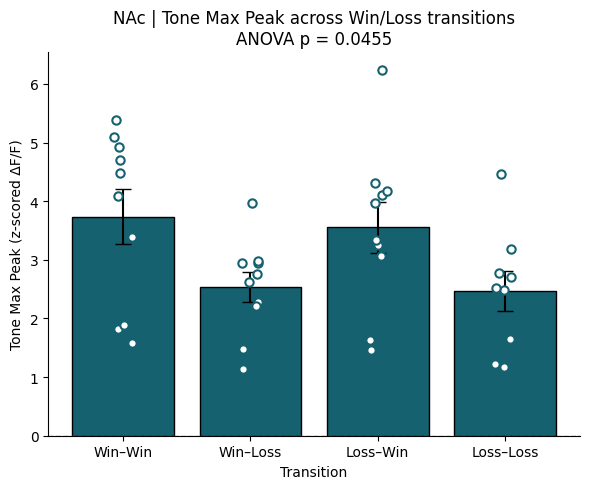

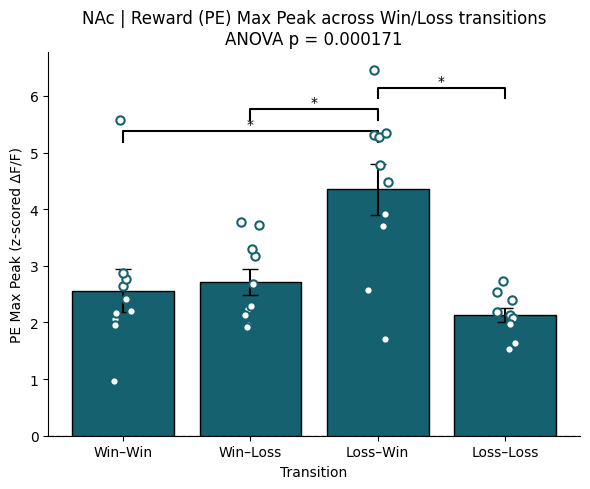

{'anova_p': 0.0001714419377252466,
 'pairwise':               comparison  p_uncorrected  p_holm_sig  cohens_d
 0    win-win vs win-loss       0.726839       False -0.159223
 1    win-win vs loss-win       0.006935        True -1.368134
 2   win-win vs loss-loss       0.300521       False  0.477092
 3   win-loss vs loss-win       0.006166        True -1.452940
 4  win-loss vs loss-loss       0.041186       False  1.001011
 5  loss-win vs loss-loss       0.000678        True  2.082240,
 'n_per_group': {'win-win': 10,
  'win-loss': 10,
  'loss-win': 10,
  'loss-loss': 9},
 'aggregation': 'subjects'}

In [13]:
# Tone Max Peak (NAc)
plot_transition_bar(
    event_df,
    metric_col="Tone Max Peak",
    brain_region="NAc",
    agg="subject",
    title="NAc | Tone Max Peak across Win/Loss transitions",
    ylabel="Tone Max Peak (z-scored ΔF/F)"
)

# Reward (PE) Max Peak (NAc)
plot_transition_bar(
    event_df,
    metric_col="PE Max Peak",
    brain_region="NAc",
    agg="subject",
    title="NAc | Reward (PE) Max Peak across Win/Loss transitions",
    ylabel="PE Max Peak (z-scored ΔF/F)"
)


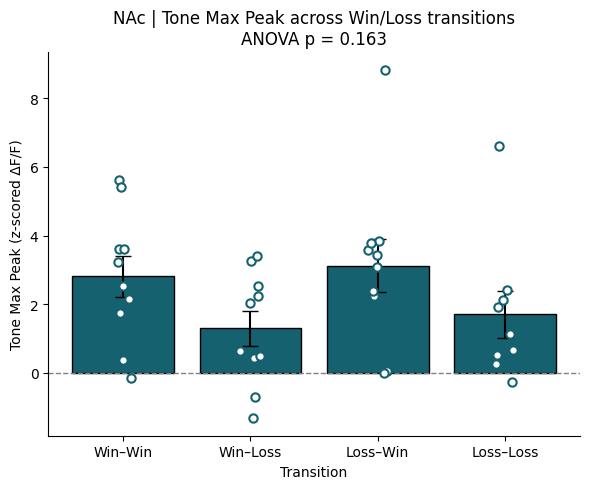

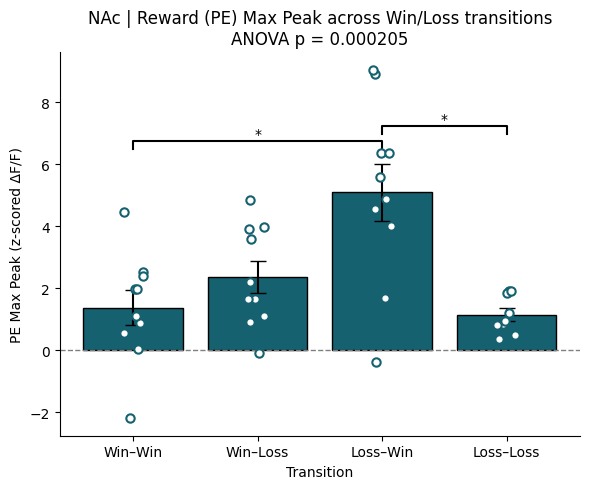

{'anova_p': 0.00020545649629016176,
 'pairwise':               comparison  p_uncorrected  p_holm_sig  cohens_d
 0    win-win vs win-loss       0.203459       False -0.590388
 1    win-win vs loss-win       0.003600        True -1.544567
 2   win-win vs loss-loss       0.715076       False  0.164607
 3   win-loss vs loss-win       0.021570       False -1.155901
 4  win-loss vs loss-loss       0.046560       False  0.980363
 5  loss-win vs loss-loss       0.001949        True  1.825174,
 'n_per_group': {'win-win': 10,
  'win-loss': 10,
  'loss-win': 10,
  'loss-loss': 9},
 'aggregation': 'subjects'}

In [14]:
# Tone Max Peak (NAc)
plot_transition_bar(
    event_df,
    metric_col="Tone AUC",
    brain_region="NAc",
    agg="subject",
    title="NAc | Tone Max Peak across Win/Loss transitions",
    ylabel="Tone Max Peak (z-scored ΔF/F)"
)

# Reward (PE) Max Peak (NAc)
plot_transition_bar(
    event_df,
    metric_col="PE AUC",
    brain_region="NAc",
    agg="subject",
    title="NAc | Reward (PE) Max Peak across Win/Loss transitions",
    ylabel="PE Max Peak (z-scored ΔF/F)"
)


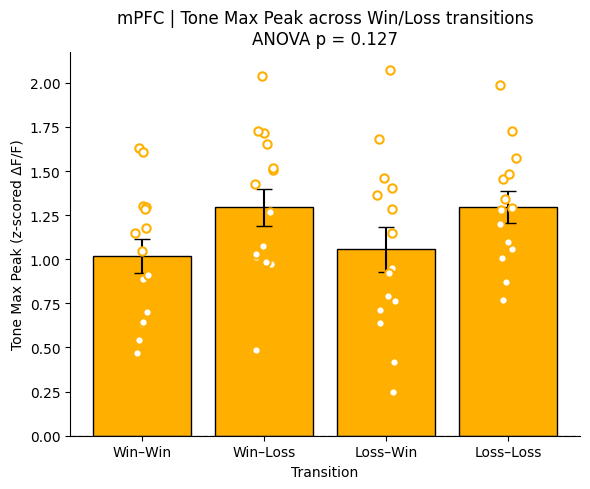

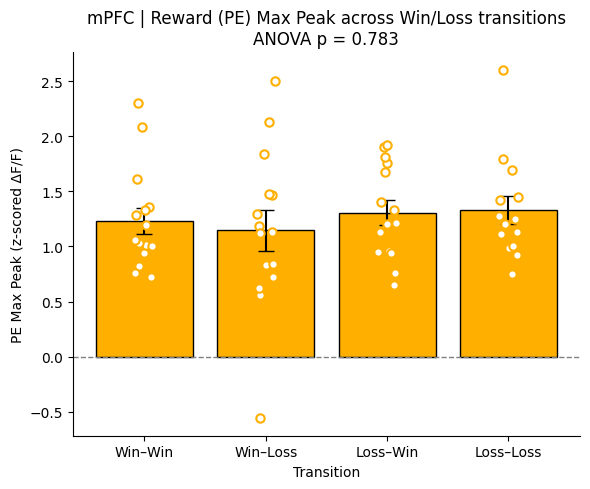

{'anova_p': 0.7833110723176725,
 'pairwise':               comparison  p_uncorrected  p_holm_sig  cohens_d
 0    win-win vs win-loss       0.689893       False  0.147496
 1    win-win vs loss-win       0.653134       False -0.165890
 2   win-win vs loss-loss       0.587247       False -0.204299
 3   win-loss vs loss-win       0.460984       False -0.273891
 4  win-loss vs loss-loss       0.421766       False -0.299238
 5  loss-win vs loss-loss       0.898408       False -0.048077,
 'n_per_group': {'win-win': 15,
  'win-loss': 15,
  'loss-win': 15,
  'loss-loss': 14},
 'aggregation': 'subjects'}

In [15]:
# Tone Max Peak (NAc)
plot_transition_bar(
    event_df,
    metric_col="Tone Max Peak",
    brain_region="mPFC",
    agg="subject",
    title="mPFC | Tone Max Peak across Win/Loss transitions",
    ylabel="Tone Max Peak (z-scored ΔF/F)"
)

# Reward (PE) Max Peak (NAc)
plot_transition_bar(
    event_df,
    metric_col="PE Max Peak",
    brain_region="mPFC",
    agg="subject",
    title="mPFC | Reward (PE) Max Peak across Win/Loss transitions",
    ylabel="PE Max Peak (z-scored ΔF/F)"
)


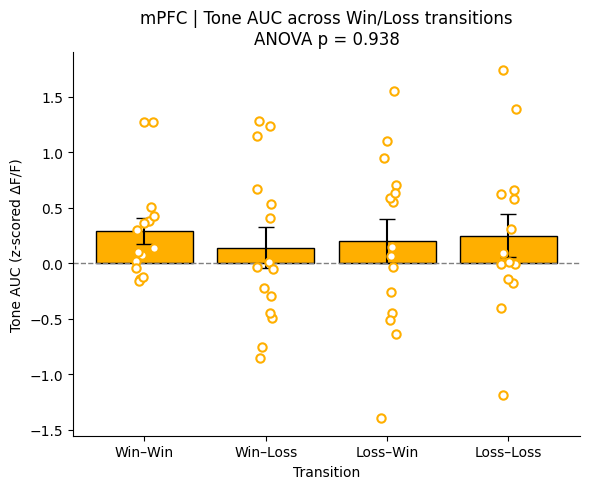

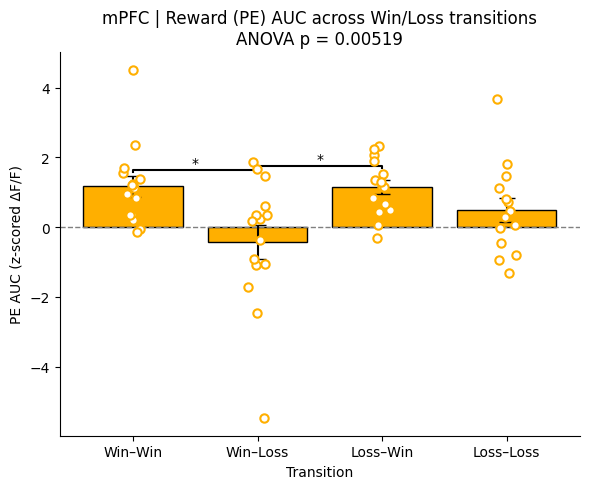

{'anova_p': 0.005192507483534693,
 'pairwise':               comparison  p_uncorrected  p_holm_sig  cohens_d
 0    win-win vs win-loss       0.009565        True  1.030669
 1    win-win vs loss-win       0.942600       False  0.026559
 2   win-win vs loss-loss       0.150525       False  0.552683
 3   win-loss vs loss-win       0.007309        True -1.097208
 4  win-loss vs loss-loss       0.132784       False -0.570270
 5  loss-win vs loss-loss       0.120636       False  0.610689,
 'n_per_group': {'win-win': 15,
  'win-loss': 15,
  'loss-win': 15,
  'loss-loss': 14},
 'aggregation': 'subjects'}

In [16]:
# Tone Max Peak (NAc)
plot_transition_bar(
    event_df,
    metric_col="Tone AUC",
    brain_region="mPFC",
    agg="subject",
    title="mPFC | Tone AUC across Win/Loss transitions",
    ylabel="Tone AUC (z-scored ΔF/F)"
)

# Reward (PE) Max Peak (NAc)
plot_transition_bar(
    event_df,
    metric_col="PE AUC",
    brain_region="mPFC",
    agg="subject",
    title="mPFC | Reward (PE) AUC across Win/Loss transitions",
    ylabel="PE AUC (z-scored ΔF/F)"
)


## Traces

In [17]:
rc_exp.build_transition_dfs()

{'win-win':    subject_name          file name  \
 0           nn5  nn5-250203-080636   
 1           pp5  pp5-250203-080636   
 2           nn1  nn1-250203-085508   
 3           nn3  nn3-250203-085508   
 4           nn6  nn6-250203-112333   
 5           pp4  pp4-250203-121223   
 6           pp1  pp1-250205-090150   
 7           pp5  pp5-250205-095320   
 8           nn8  nn8-250205-104235   
 9           pp2  pp2-250205-122507   
 10          pp4  pp4-250205-122507   
 11          pp7  pp7-250205-131504   
 12          nn6  nn6-250204-075106   
 13          pp2  pp2-250204-095252   
 14          pp1  pp1-250204-095252   
 15          pp8  pp8-250204-104135   
 16          pp5  pp5-250204-104135   
 17          nn8  nn8-250204-113128   
 18          nn5  nn5-250204-113128   
 19          pp3  pp3-250204-122327   
 20          nn2  nn2-250206-053033   
 21          pp6  pp6-250206-062728   
 22          pp7  pp7-250206-062728   
 23          nn6  nn6-250206-073116   
 24          n

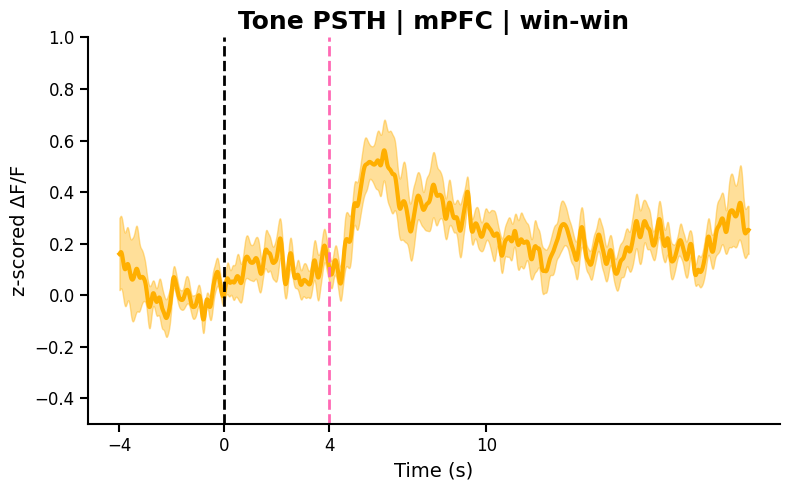

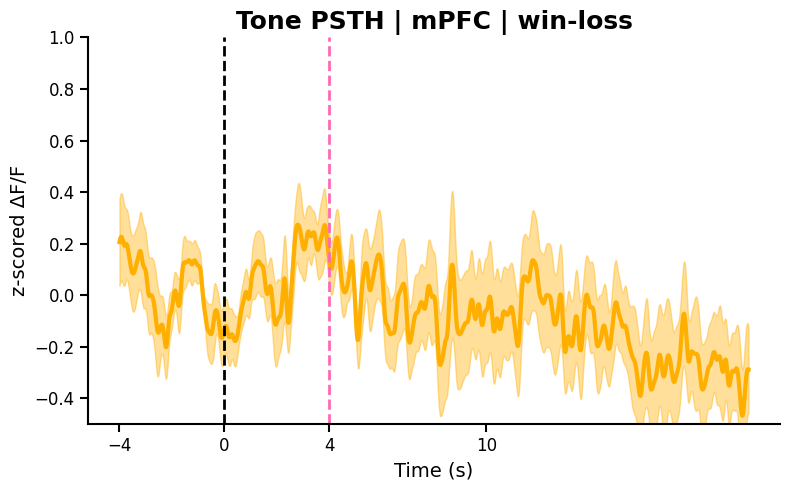

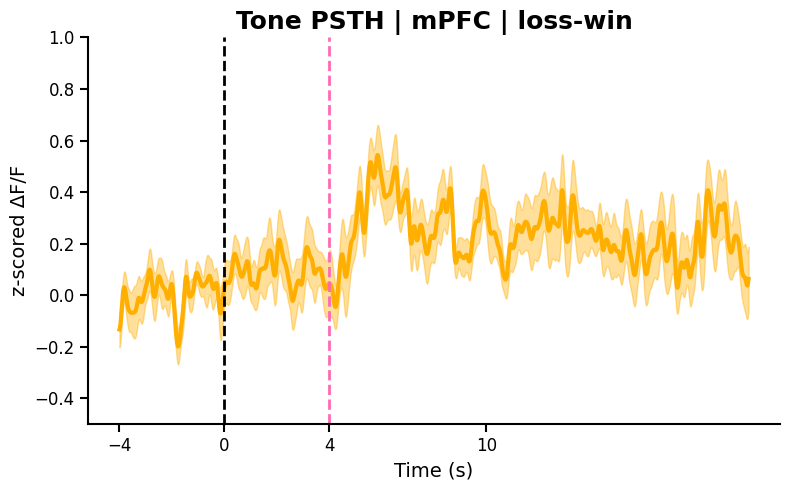

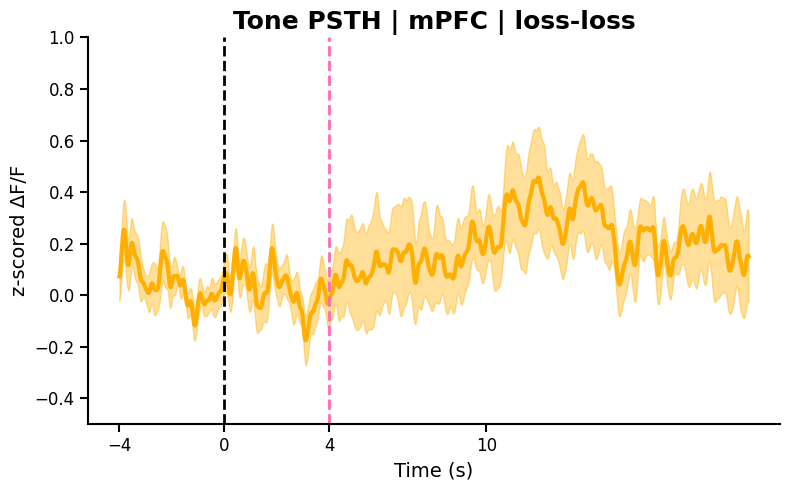

In [18]:

for tr in ["win-win", "win-loss", "loss-win", "loss-loss"]:
    rc_exp.plot_transition_psth(
        transition=tr,
        event_type="Tone",
        brain_region="mPFC",
        time_window_s=(-4, 20),
        ylim=(-0.5, 1)
)


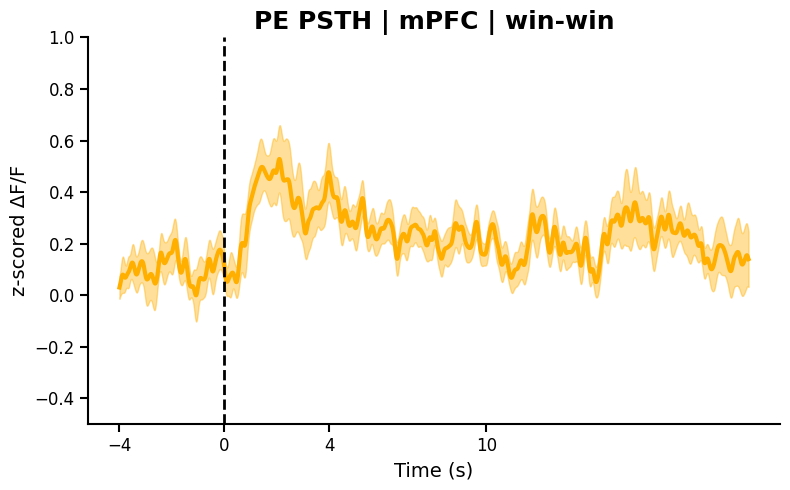

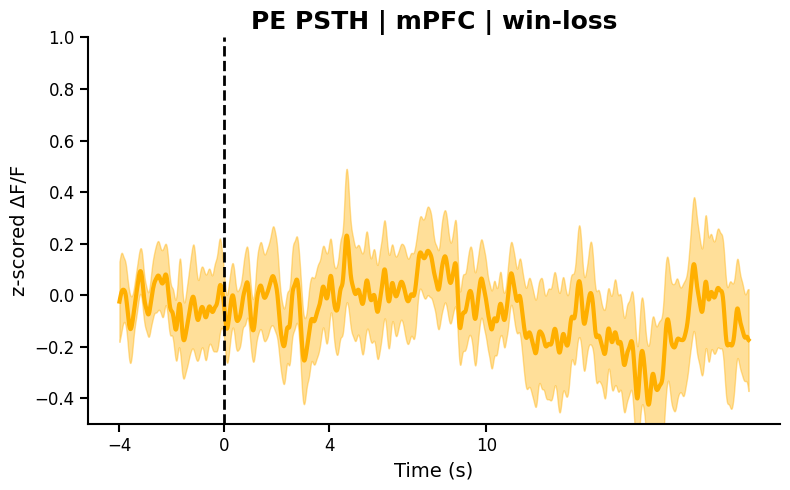

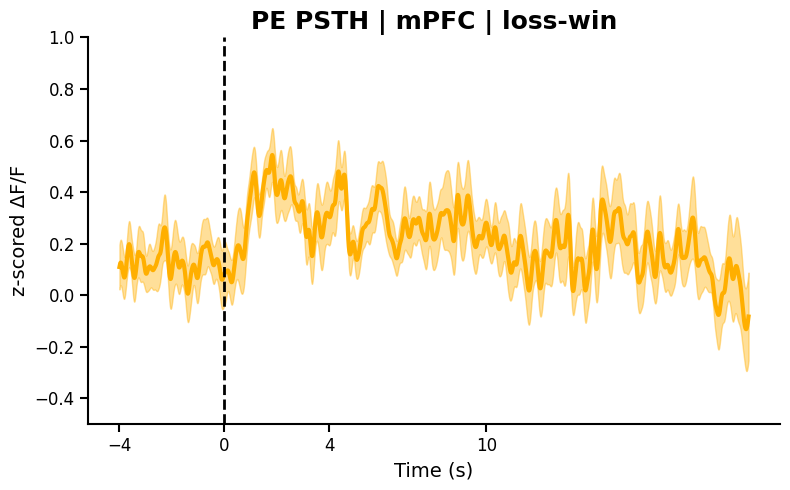

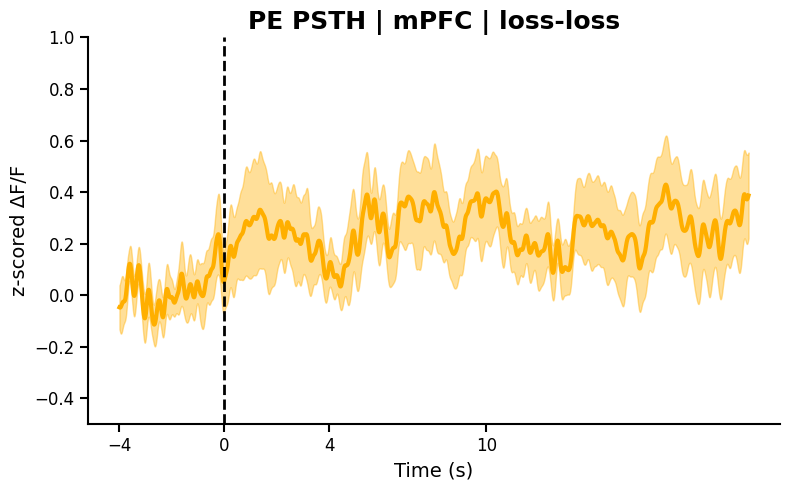

In [19]:

for tr in ["win-win", "win-loss", "loss-win", "loss-loss"]:
    rc_exp.plot_transition_psth(
        transition=tr,
        event_type="PE",
        brain_region="mPFC",
        time_window_s=(-4, 20),
        ylim=(-0.5, 1),
        reward_line=False
)


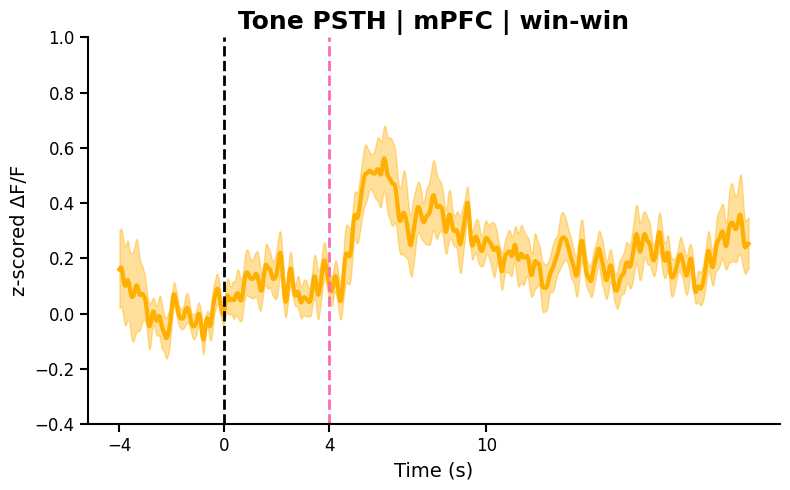

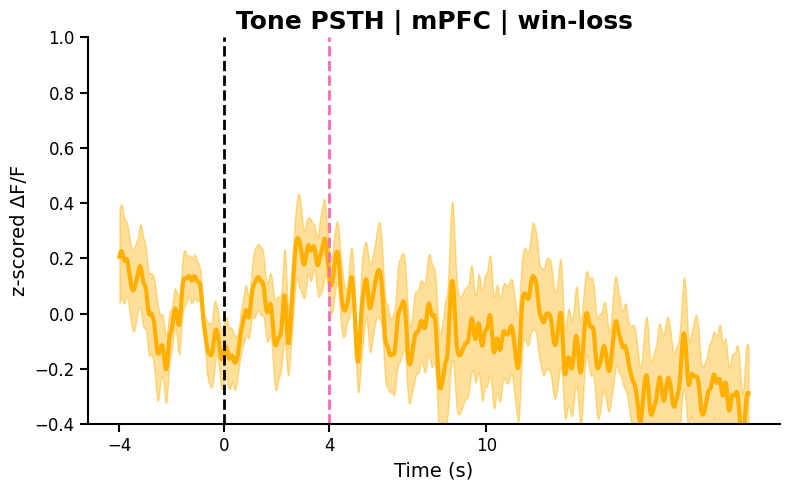

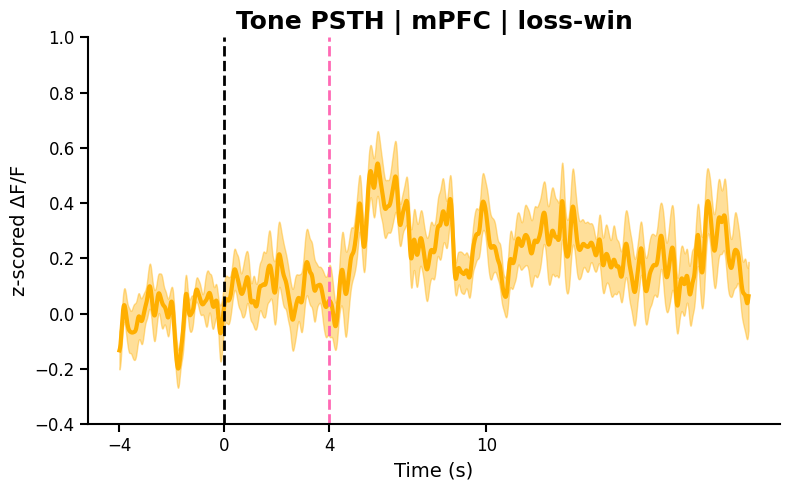

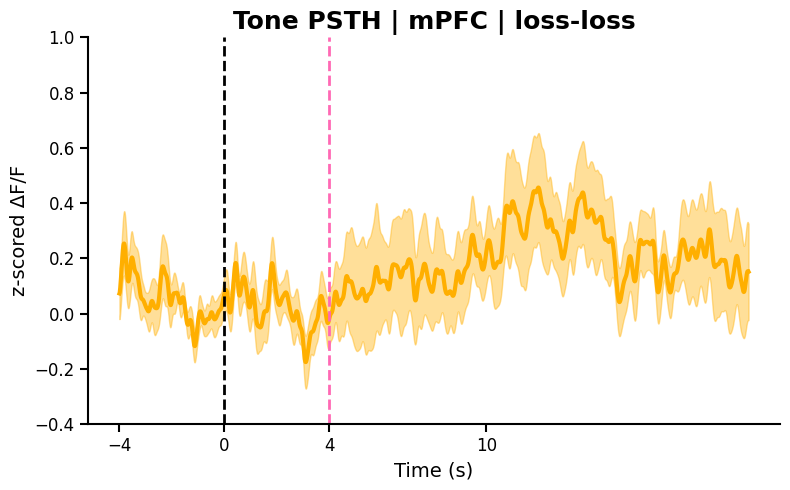

In [20]:
for tr in ["win-win", "win-loss", "loss-win", "loss-loss"]:

    rc_exp.plot_transition_psth(
        tr, "Tone", "mPFC", ylim=(-0.4, 1)
    )


In [21]:
x

NameError: name 'x' is not defined

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _unwrap_1d_array(x):
    """
    Convert nested containers like [array], [[array]], array([[...]]) to a clean 1D float array.
    Returns None if empty/unusable.
    """
    if x is None:
        return None

    # unwrap singletons repeatedly: [something] -> something
    while isinstance(x, (list, tuple, np.ndarray)) and len(np.atleast_1d(x)) == 1:
        try:
            x = x[0]
        except Exception:
            break

    try:
        arr = np.asarray(x, dtype=float).ravel()
    except Exception:
        return None

    if arr.size == 0:
        return None

    return arr


def _trim_to_common_length(arr_list, t_list=None):
    """
    Given a list of 1D arrays (and optional matching time axes),
    trim everything to the shortest valid length and return stacked matrix and one time axis.
    """
    arr_list = [a for a in arr_list if isinstance(a, np.ndarray) and a.ndim == 1 and a.size > 0]
    if not arr_list:
        return None, None

    Lmin = min(a.size for a in arr_list)
    arr_list = [a[:Lmin] for a in arr_list]

    if t_list is not None:
        t_list = [t for t in t_list if isinstance(t, np.ndarray) and t.ndim == 1 and t.size > 0]
        if t_list:
            tmin = min(t.size for t in t_list)
            L = min(Lmin, tmin)
            arr_list = [a[:L] for a in arr_list]
            t0 = t_list[0][:L]
        else:
            t0 = np.arange(Lmin, dtype=float)
    else:
        t0 = np.arange(Lmin, dtype=float)

    M = np.vstack(arr_list)  # (n, L)
    return M, t0

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NAC_COLOR  = "#15616F"
MPFC_COLOR = "#FFAF00"

def _unwrap_singleton_list(x):
    """
    Your columns often look like: [array([...])] instead of array([...]).
    This unwraps one layer safely.
    """
    if isinstance(x, list) and len(x) == 1:
        return x[0]
    return x

def compute_subject_mean_traces_by_condition(
    event_df: pd.DataFrame,
    event_type: str,                 # "Tone" or "PE"
    condition_col: str,              # e.g. "transition"
    condition_value: str,
) -> pd.DataFrame:
    """
    Returns per-subject mean trace for a given condition and event_type.
    Output columns: subject_name, mean_trace, time_axis
    """
    zcol = f"{event_type}_Zscore"
    tcol = f"{event_type}_Time_Axis"

    # 1) filter to condition
    df = event_df[event_df[condition_col] == condition_value].copy()
    if df.empty:
        return pd.DataFrame(columns=["subject_name", "mean_trace", "time_axis"])

    rows = []

    # 2) per subject: build session-mean traces, then subject-mean trace
    for subj, sdf in df.groupby("subject_name"):
        session_means = []
        session_taxes = []

        for _, r in sdf.iterrows():
            # Each row corresponds to a "session/event instance" in your event_df,
            # but the stored zcol may still be a list of arrays (multiple events).
            zraw = r.get(zcol, None)
            traw = r.get(tcol, None)

            if zraw is None or traw is None:
                continue

            zraw = _unwrap_singleton_list(zraw)
            traw = _unwrap_singleton_list(traw)

            # If it's a list-of-arrays, average across events inside the session
            if isinstance(zraw, (list, tuple)):
                z_list = [np.asarray(x, dtype=float) for x in zraw if x is not None]
                if len(z_list) == 0:
                    continue
                L = min(len(x) for x in z_list)
                Z = np.vstack([x[:L] for x in z_list])
                sess_mean = np.nanmean(Z, axis=0)
                t = np.asarray(traw[0] if isinstance(traw, (list, tuple)) else traw, dtype=float)[:L]
            else:
                # Otherwise assume it's a single array trace
                z = np.asarray(zraw, dtype=float)
                t = np.asarray(traw, dtype=float)

                # Guard: must match length
                L = min(len(z), len(t))
                sess_mean = z[:L]
                t = t[:L]

            # Skip if all NaN
            if np.all(np.isnan(sess_mean)):
                continue

            session_means.append(sess_mean)
            session_taxes.append(t)

        if len(session_means) == 0:
            continue

        # 3) trim sessions to common shortest length and average across sessions
        Lmin = min(len(x) for x in session_means)
        S = np.vstack([x[:Lmin] for x in session_means])
        subj_mean = np.nanmean(S, axis=0)

        # Choose a representative time axis (also trimmed)
        t = session_taxes[0][:Lmin]

        rows.append({
            "subject_name": subj,
            "mean_trace": subj_mean,
            "time_axis": t
        })

    return pd.DataFrame(rows)

def plot_group_mean_traces_condition(
    event_df: pd.DataFrame,
    event_type: str,                 # "Tone" or "PE"
    brain_region: str,               # "NAc" or "mPFC"
    condition_value: str,            # "win-win", etc.
    condition_col: str = "transition",
    ylim: tuple = None,
    figsize=(8,5),
    title: str = None,
):
    """
    One plot = one mean line + SEM band. No individual traces.
    """
    subj_traces = compute_subject_mean_traces_by_condition(
        event_df=event_df,
        event_type=event_type,
        condition_col=condition_col,
        condition_value=condition_value
    )

    if brain_region == "NAc":
        grp = subj_traces[subj_traces["subject_name"].str.startswith("n")]
        color = NAC_COLOR
    else:
        grp = subj_traces[subj_traces["subject_name"].str.startswith("p")]
        color = MPFC_COLOR

    if grp.empty:
        print(f"No data for {event_type} | {brain_region} | {condition_value}")
        return

    # stack subject mean traces to compute group mean ± SEM
    Lmin = min(len(x) for x in grp["mean_trace"].values)
    M = np.vstack([np.asarray(x, dtype=float)[:Lmin] for x in grp["mean_trace"].values])
    mean_trace = np.nanmean(M, axis=0)
    sem_trace  = np.nanstd(M, axis=0, ddof=1) / np.sqrt(M.shape[0])

    t0 = np.asarray(grp.iloc[0]["time_axis"], dtype=float)[:Lmin]

    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(t0, mean_trace, color=color, lw=3)
    ax.fill_between(t0, mean_trace - sem_trace, mean_trace + sem_trace, color=color, alpha=0.35)

    # event lines
    ax.axvline(0, color="k", ls="--", lw=2)
    if event_type.lower() in ("tone",):
        ax.axvline(4, color="#FF69B4", ls="--", lw=2)

    ax.set_xlabel("Time (s)", fontsize=14)
    ax.set_ylabel("z-scored ΔF/F", fontsize=14)

    ax.set_title(title or f"{event_type} PSTH | {brain_region} | {condition_value}", fontsize=18, fontweight="bold")

    if ylim is not None:
        ax.set_ylim(ylim)

    # sane ticks: use the real time axis range
    xmin, xmax = float(np.nanmin(t0)), float(np.nanmax(t0))
    ax.set_xlim(xmin, xmax)
    # reasonable default tick marks for your typical ranges
    if xmin <= -4 and xmax >= 10:
        ax.set_xticks([-4, 0, 4, 10])
    elif xmin <= 0 and xmax >= 10:
        ax.set_xticks([0, 4, 10])

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_linewidth(1.5)
    ax.spines["left"].set_linewidth(1.5)

    plt.tight_layout()
    plt.show()


from scipy.stats import ttest_ind

def plot_transition_bar(
    event_df: pd.DataFrame,
    metric_col: str,                 # e.g., "Tone Max Peak" or "PE Max Peak"
    brain_region: str,               # "NAc" or "mPFC"
    condition_col: str = "condition",
    conditions=("win-win","win-loss","loss-win","loss-loss"),
    nac_color="#15616F",
    mpfc_color="#FFAF00",
    figsize=(7,5),
):
    # region filter
    prefix = "n" if brain_region == "NAc" else "p"
    df = event_df[event_df["subject_name"].str.startswith(prefix)].copy()
    if df.empty:
        print(f"No data for region {brain_region}")
        return

    # subject-level means per condition
    subj_vals = {}
    for cond in conditions:
        d = df[df[condition_col] == cond][["subject_name", metric_col]].copy()
        if d.empty:
            subj_vals[cond] = np.array([])
            continue
        # if metric is nested, unwrap; if numeric, keep
        def _metric_to_float(x):
            if isinstance(x, (list, tuple, np.ndarray)):
                a = _unwrap_1d_array(x)
                if a is None:
                    return np.nan
                # if someone accidentally stored a 1D trace here, collapse
                return float(np.nanmean(a))
            try:
                return float(x)
            except Exception:
                return np.nan

        d[metric_col] = d[metric_col].apply(_metric_to_float)
        # mean across events -> one per subject
        v = d.groupby("subject_name")[metric_col].mean().dropna().values
        subj_vals[cond] = v

    # compute bar means/SEMs
    means = [np.nanmean(subj_vals[c]) if len(subj_vals[c]) else np.nan for c in conditions]
    sems  = [np.nanstd(subj_vals[c], ddof=1)/np.sqrt(len(subj_vals[c])) if len(subj_vals[c])>1 else 0.0 for c in conditions]

    color = nac_color if brain_region == "NAc" else mpfc_color

    fig, ax = plt.subplots(figsize=figsize)
    x = np.arange(len(conditions))
    ax.bar(x, means, yerr=sems, capsize=6, color=color, edgecolor="k", linewidth=2)

    # overlay subject points at bar centers
    for i, c in enumerate(conditions):
        v = subj_vals[c]
        if len(v):
            ax.scatter(np.full(len(v), i), v, facecolors="white", edgecolors="black", s=80, zorder=3)

    ax.set_xticks(x)
    ax.set_xticklabels(conditions, fontsize=12)
    ax.set_ylabel(metric_col, fontsize=14)
    ax.set_title(f"{brain_region} | {metric_col}", fontsize=16, fontweight="bold")
    ax.axhline(0, color="gray", ls="--", lw=1)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()

    # significance: pairwise Welch t-tests (prints; you can also annotate if you want)
    stats = {}
    for i in range(len(conditions)):
        for j in range(i+1, len(conditions)):
            a = subj_vals[conditions[i]]
            b = subj_vals[conditions[j]]
            if len(a) < 2 or len(b) < 2:
                stats[(conditions[i], conditions[j])] = {"p": np.nan, "t": np.nan, "d": np.nan}
                continue
            t, p = ttest_ind(a, b, equal_var=False, nan_policy="omit")
            # Cohen's d (pooled SD)
            sd1, sd2 = np.nanstd(a, ddof=1), np.nanstd(b, ddof=1)
            pooled = np.sqrt(((len(a)-1)*sd1**2 + (len(b)-1)*sd2**2) / (len(a)+len(b)-2))
            d = (np.nanmean(a) - np.nanmean(b)) / pooled if pooled > 0 else np.nan
            stats[(conditions[i], conditions[j])] = {"p": float(p), "t": float(t), "d": float(d)}

    plt.show()
    return stats


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NAC_COLOR  = "#15616F"
MPFC_COLOR = "#FFAF00"

def _to_1d_array(x):
    """Convert nested/list/singleton representations to a 1D numpy array."""
    if x is None:
        return None
    # unwrap singleton list like [array([...])]
    if isinstance(x, list) and len(x) == 1:
        x = x[0]
    arr = np.asarray(x, dtype=float)
    if arr.ndim != 1:
        arr = arr.ravel()
    return arr

def _normalize_condition_series(s: pd.Series) -> pd.Series:
    """Force condition column into comparable strings."""
    return s.astype(str).str.strip().str.lower()

def compute_subject_mean_traces_by_condition_v2(
    event_df: pd.DataFrame,
    event_type: str,                 # "Tone" or "PE"
    condition_col: str,              # e.g. "transition"
    condition_value: str,            # e.g. "win-win"
    session_col: str = "file name",  # session identifier in your df
    verbose: bool = True
) -> pd.DataFrame:
    """
    Returns per-subject mean trace for a given condition and event_type.

    Handles BOTH cases:
    A) event_df rows are PER-EVENT: Tone_Zscore is a 1D array per row
    B) event_df rows are PER-SESSION with lists: Tone_Zscore is list-of-arrays per row
    """
    zcol = f"{event_type}_Zscore"
    tcol = f"{event_type}_Time_Axis"

    if condition_col not in event_df.columns:
        raise KeyError(f"'{condition_col}' not found. Available columns: {list(event_df.columns)}")

    if zcol not in event_df.columns or tcol not in event_df.columns:
        raise KeyError(f"Need '{zcol}' and '{tcol}' in event_df. Available columns: {list(event_df.columns)}")

    df = event_df.copy()

    # Normalize condition labels robustly
    df["_cond_norm"] = _normalize_condition_series(df[condition_col])
    target = str(condition_value).strip().lower()

    # Filter to condition
    df = df[df["_cond_norm"] == target].copy()

    if verbose:
        uniq = event_df[condition_col].astype(str).unique()[:20]
        print(f"[DEBUG] condition_col='{condition_col}' unique examples: {uniq}")
        print(f"[DEBUG] Filtering to '{target}' -> rows kept: {len(df)}")

    if df.empty:
        return pd.DataFrame(columns=["subject_name", "mean_trace", "time_axis"])

    rows = []

    # We compute: subject -> session_mean (collapse events within session if needed) -> subject_mean
    for subj, sdf in df.groupby("subject_name"):
        session_means = []
        session_taxes = []

        # group by session so we don't overweight sessions with more events
        if session_col in sdf.columns:
            session_groups = sdf.groupby(session_col)
        else:
            # fallback: treat each row as its own session if no session_col
            session_groups = [(i, r.to_frame().T) for i, r in sdf.iterrows()]

        for _, g in session_groups:
            # collect traces inside this session-group
            traces = []
            taxes  = []

            for _, r in g.iterrows():
                zraw = r.get(zcol, None)
                traw = r.get(tcol, None)

                # Case B: list-of-arrays stored in a single cell
                if isinstance(zraw, list) and len(zraw) > 0 and not isinstance(zraw[0], (float, int, np.floating, np.integer)):
                    for zz in zraw:
                        arrz = _to_1d_array(zz)
                        if arrz is None or np.all(np.isnan(arrz)):
                            continue
                        traces.append(arrz)

                    # time axis might also be list-of-arrays
                    if isinstance(traw, list) and len(traw) > 0:
                        arrt = _to_1d_array(traw[0])
                    else:
                        arrt = _to_1d_array(traw)
                    if arrt is not None:
                        taxes.append(arrt)

                else:
                    # Case A: per-event row where cell is array or singleton list
                    arrz = _to_1d_array(zraw)
                    arrt = _to_1d_array(traw)
                    if arrz is None or arrt is None:
                        continue
                    L = min(len(arrz), len(arrt))
                    arrz, arrt = arrz[:L], arrt[:L]
                    if np.all(np.isnan(arrz)):
                        continue
                    traces.append(arrz)
                    taxes.append(arrt)

            if len(traces) == 0:
                continue

            # Make all traces same length within session
            Lmin = min(len(x) for x in traces)
            Z = np.vstack([x[:Lmin] for x in traces])
            sess_mean = np.nanmean(Z, axis=0)

            # Pick a representative time axis (trimmed)
            t = taxes[0][:Lmin] if len(taxes) > 0 else np.arange(Lmin, dtype=float)

            session_means.append(sess_mean)
            session_taxes.append(t)

        if len(session_means) == 0:
            continue

        # Average across sessions (equal weight per session)
        Lmin = min(len(x) for x in session_means)
        S = np.vstack([x[:Lmin] for x in session_means])
        subj_mean = np.nanmean(S, axis=0)
        t = session_taxes[0][:Lmin]

        rows.append({"subject_name": subj, "mean_trace": subj_mean, "time_axis": t})

    return pd.DataFrame(rows).dropna(subset=["mean_trace"])

def plot_group_mean_traces_condition_v2(
    event_df: pd.DataFrame,
    event_type: str,                 # "Tone" or "PE"
    brain_region: str,               # "NAc" or "mPFC"
    condition_value: str,            # "win-win", etc.
    condition_col: str = "transition",
    session_col: str = "file name",
    ylim: tuple = None,
    figsize=(8,5),
    title: str = None,
    verbose: bool = True
):
    subj_traces = compute_subject_mean_traces_by_condition_v2(
        event_df=event_df,
        event_type=event_type,
        condition_col=condition_col,
        condition_value=condition_value,
        session_col=session_col,
        verbose=verbose
    )

    if brain_region == "NAc":
        grp = subj_traces[subj_traces["subject_name"].astype(str).str.startswith("n")]
        color = NAC_COLOR
    else:
        grp = subj_traces[subj_traces["subject_name"].astype(str).str.startswith("p")]
        color = MPFC_COLOR

    if verbose:
        print(f"[DEBUG] {event_type} | {brain_region} | {condition_value}: subjects={len(grp)}")

    if grp.empty:
        print(f"No data for {event_type} | {brain_region} | {condition_value}")
        return

    # Stack subjects
    Lmin = min(len(x) for x in grp["mean_trace"].values)
    M = np.vstack([np.asarray(x, dtype=float)[:Lmin] for x in grp["mean_trace"].values])
    mean_trace = np.nanmean(M, axis=0)
    sem_trace  = np.nanstd(M, axis=0, ddof=1) / np.sqrt(M.shape[0])

    t = np.asarray(grp.iloc[0]["time_axis"], dtype=float)[:Lmin]

    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(t, mean_trace, color=color, lw=3)
    ax.fill_between(t, mean_trace - sem_trace, mean_trace + sem_trace, color=color, alpha=0.35)

    ax.axvline(0, color="k", ls="--", lw=2)
    if event_type.lower() == "tone":
        ax.axvline(4, color="#FF69B4", ls="--", lw=2)

    ax.set_xlabel("Time (s)", fontsize=14)
    ax.set_ylabel("z-scored ΔF/F", fontsize=14)
    ax.set_title(title or f"{event_type} PSTH | {brain_region} | {condition_value}", fontsize=18, fontweight="bold")

    if ylim is not None:
        ax.set_ylim(ylim)

    ax.set_xlim(float(np.nanmin(t)), float(np.nanmax(t)))

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_linewidth(1.5)
    ax.spines["left"].set_linewidth(1.5)

    plt.tight_layout()
    plt.show()


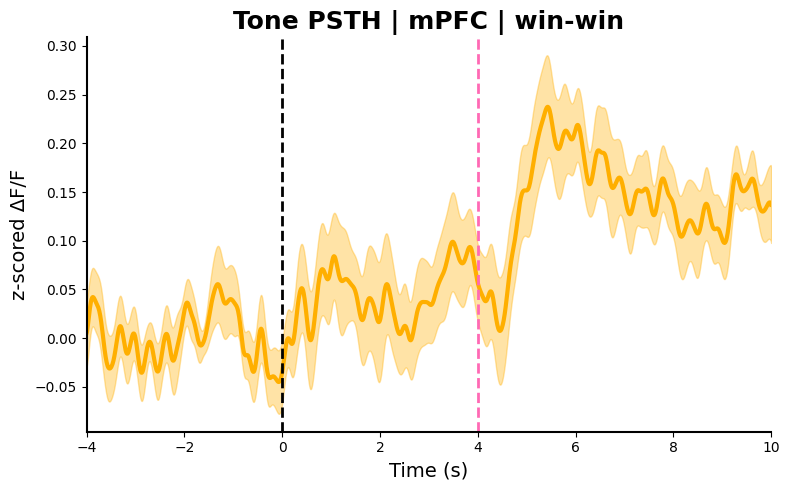

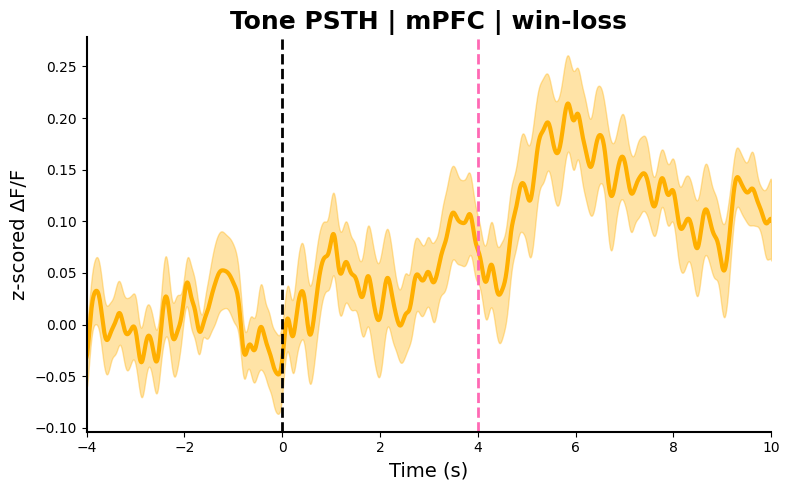

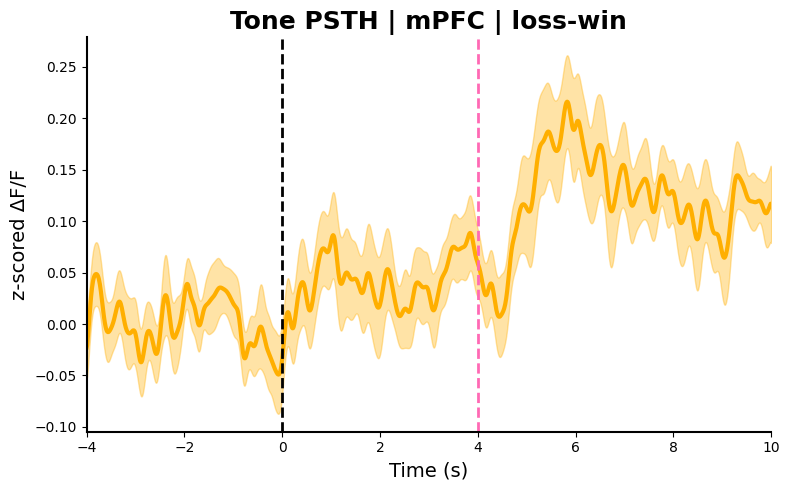

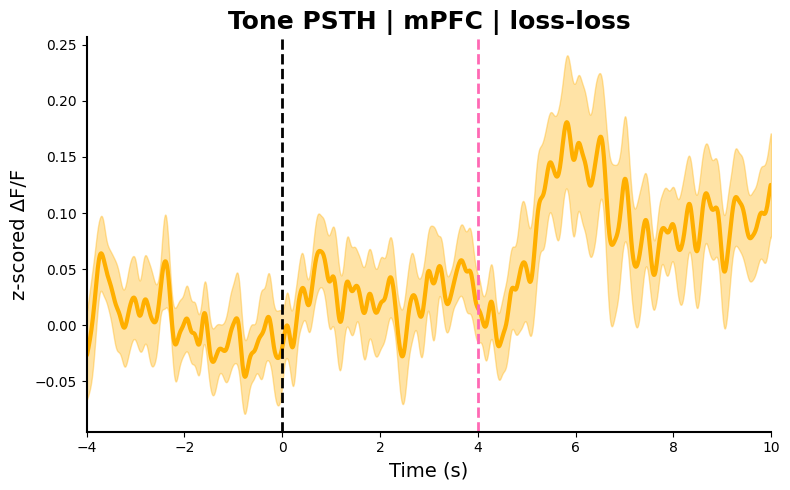

In [ ]:
conditions = ["win-win", "win-loss", "loss-win", "loss-loss"]

for cond in conditions:
    plot_group_mean_traces_condition(
        event_df=event_df,
        event_type="Tone",
        brain_region="mPFC",
        condition_value=cond,
        condition_col="transition",
        ylim=None
    )
